# MySpotify -- Dataset Exploration
Million Song Dataset (MSD) -- parsing and EDA for all 4 files.

**Files expected** (local folder, Kaggle input mount, or Kaggle download fallback):
- `p02_unique_tracks.txt`
- `p02_msd_tagtraum_cd2.cls`
- `p02_train_triplets.txt` (unzipped)
- `p02_mxm_dataset_train.txt` (unzipped)

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.data.loader import MySpotifyRecommender

In [2]:
rs = MySpotifyRecommender.from_files(Path.cwd().parent / "data", download=True, triplets_sample_rows=100_000)

Data dir    : /home/samy/MySpotify/data
Source      : cleaned CSVs (/home/samy/MySpotify/data/csv)

  tracks      (1000000, 4)
  genres      (280831, 3)
  triplets    (100000, 3)
  lyrics_long (16845822, 3)


In [3]:
print(rs.genres.head(10))
print(rs.triplets.head(10))
print(rs.tracks.head(10))
print(rs.lyrics_long.head(10))

             track_id majority_genre minority_genre
0  TRAAAAK128F9318786           Rock            NaN
1  TRAAAAW128F429D538            Rap            NaN
2  TRAAABD128F429CF47           Rock            RnB
3  TRAAADJ128F4287B47           Rock            NaN
4  TRAAADZ128F9348C2E          Latin            NaN
5  TRAAAED128E0783FAB           Jazz            NaN
6  TRAAAEF128F4273421           Rock            NaN
7  TRAAAEM128F93347B9     Electronic            NaN
8  TRAAAFD128F92F423A           Punk           Rock
9  TRAAAGF12903CEC202            Pop            NaN
                                    user_id             song_id  play_count
0  b80344d063b5ccb3212f76538f3d9e43d87dca9e  SOAKIMP12A8C130995           1
1  b80344d063b5ccb3212f76538f3d9e43d87dca9e  SOAPDEY12A81C210A9           1
2  b80344d063b5ccb3212f76538f3d9e43d87dca9e  SOBBMDR12A8C13253B           2
3  b80344d063b5ccb3212f76538f3d9e43d87dca9e  SOBFNSP12AF72A0E22           1
4  b80344d063b5ccb3212f76538f3d9e43d87dca9e  SOB

## 1. Tracks

In [4]:
print(f"Tracks shape: {rs.tracks.shape}")
print(f"Unique artists: {rs.tracks['artist'].nunique()}")
rs.tracks.head(10)

Tracks shape: (1000000, 4)
Unique artists: 72665


,track_id,song_id,artist,title
0,TRMMMYQ128F932D901,SOQMMHC12AB0180CB8,Faster Pussy cat,Silent Night
1,TRMMMKD128F425225D,SOVFVAK12A8C1350D9,Karkkiautomaatti,Tanssi vaan
2,TRMMMRX128F93187D9,SOGTUKN12AB017F4F1,Hudson Mohawke,No One Could Ever
3,TRMMMCH128F425532C,SOBNYVR12A8C13558C,Yerba Brava,Si Vos Querés
4,TRMMMWA128F426B589,SOHSBXH12A8C13B0DF,Der Mystic,Tangle Of Aspens
5,TRMMMXN128F42936A5,SOZVAPQ12A8C13B63C,David Montgomery,"Symphony No. 1 G minor ""Sinfonie Serieuse""/All..."
6,TRMMMLR128F1494097,SOQVRHI12A6D4FB2D7,Sasha / Turbulence,We Have Got Love
7,TRMMMBB12903CB7D21,SOEYRFT12AB018936C,Kris Kross,2 Da Beat Ch'yall
8,TRMMMHY12903CB53F1,SOPMIYT12A6D4F851E,Joseph Locke,Goodbye
9,TRMMMML128F4280EE9,SOJCFMH12A8C13B0C2,The Sun Harbor's Chorus-Documentary Recordings,Mama_ mama can't you see ?


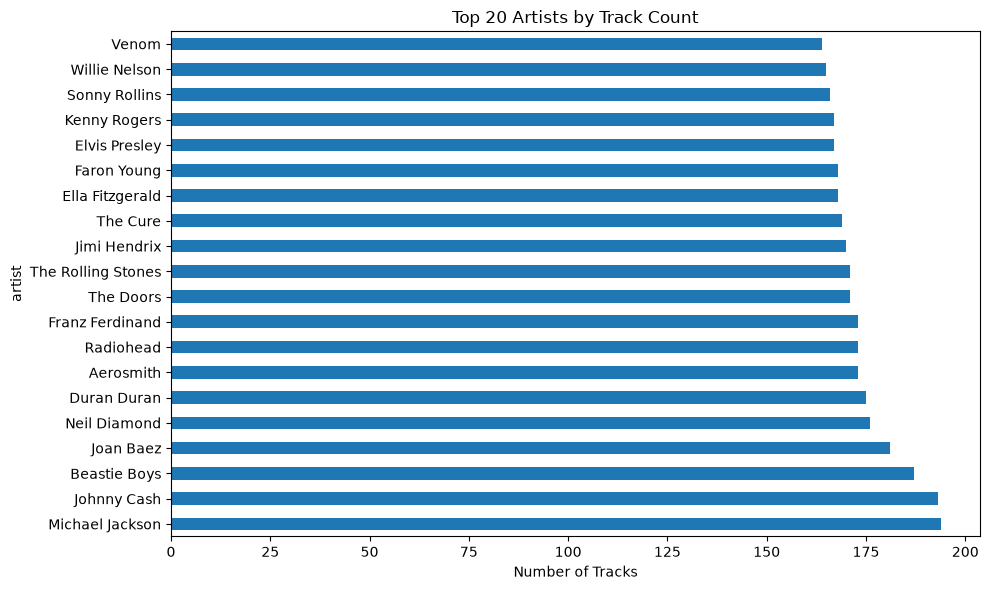

In [5]:
top_artists = rs.tracks["artist"].value_counts().head(20)
top_artists.plot(kind="barh", figsize=(10, 6), title="Top 20 Artists by Track Count")
plt.xlabel("Number of Tracks")
plt.tight_layout()
plt.show()

## 2. Genres

In [6]:
print(f"Genres shape: {rs.genres.shape}")
print(f"Unique majority genres: {rs.genres['majority_genre'].nunique()}")
rs.genres.head()

Genres shape: (280831, 3)
Unique majority genres: 15


,track_id,majority_genre,minority_genre
0,TRAAAAK128F9318786,Rock,NaN
1,TRAAAAW128F429D538,Rap,NaN
2,TRAAABD128F429CF47,Rock,RnB
3,TRAAADJ128F4287B47,Rock,NaN
4,TRAAADZ128F9348C2E,Latin,NaN


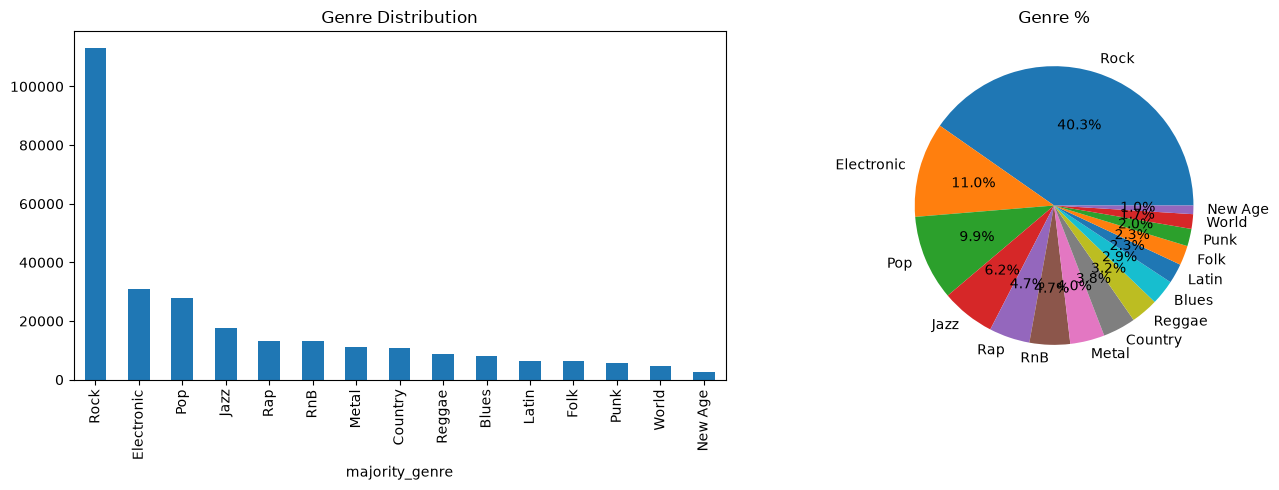

In [7]:
genre_counts = rs.genres["majority_genre"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
genre_counts.plot(kind="bar", ax=axes[0], title="Genre Distribution")
genre_counts.plot(kind="pie", ax=axes[1], autopct="%1.1f%%", title="Genre %")
axes[1].set(ylabel="")
plt.tight_layout()
plt.show()

## 3. Triplets (User-Song Interactions)

In [8]:
print(f"Triplets shape: {rs.triplets.shape}")
print(f"Unique users: {rs.triplets['user_id'].nunique()}")
print(f"Unique songs: {rs.triplets['song_id'].nunique()}")
print(f"Mean play count: {rs.triplets['play_count'].mean():.2f}")
print(f"Max play count: {rs.triplets['play_count'].max()}")

Triplets shape: (100000, 3)
Unique users: 2042
Unique songs: 44458
Mean play count: 2.90
Max play count: 1890


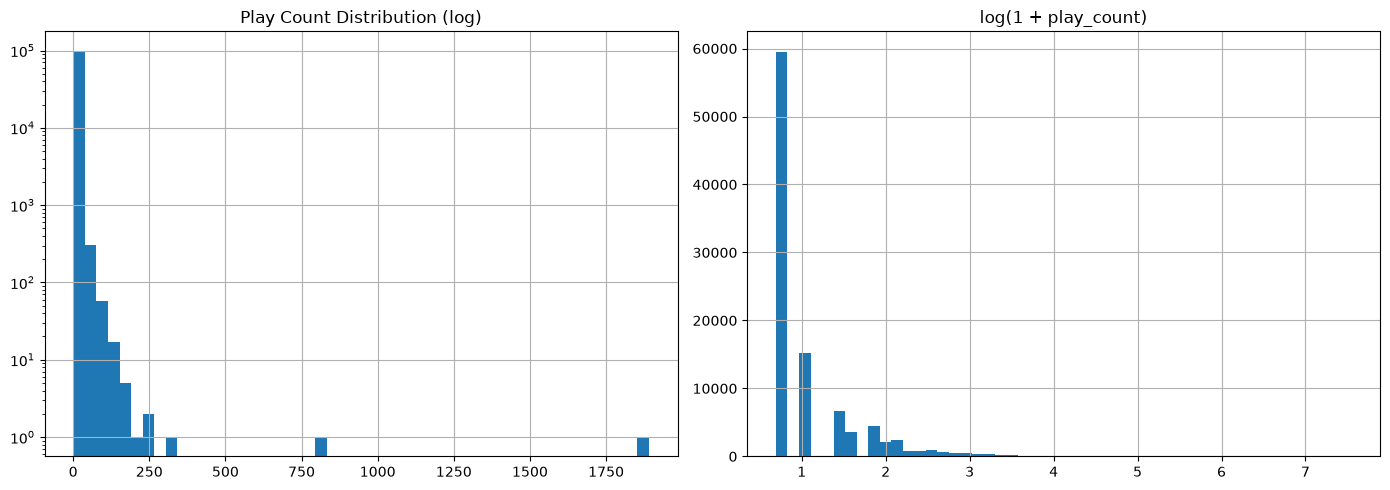

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rs.triplets["play_count"].hist(bins=50, ax=axes[0], log=True)
axes[0].set_title("Play Count Distribution (log)")
np.log1p(rs.triplets["play_count"]).hist(bins=50, ax=axes[1])
axes[1].set_title("log(1 + play_count)")
plt.tight_layout()
plt.show()

## 4. Lyrics (Bag-of-Words)

In [10]:
print(f"Lyrics long shape: {rs.lyrics_long.shape}")
print(f"Unique tracks with lyrics: {rs.lyrics_long['track_id'].nunique()}")
print(f"Vocabulary size: {rs.lyrics_long['word'].nunique()}")
rs.lyrics_long.head()

Lyrics long shape: (16845822, 3)
Unique tracks with lyrics: 210519
Vocabulary size: 4999


,track_id,word,count
0,TRAAAAV128F421A322,the,6
1,TRAAAAV128F421A322,you,4
2,TRAAAAV128F421A322,to,2
3,TRAAAAV128F421A322,and,2
4,TRAAAAV128F421A322,a,5


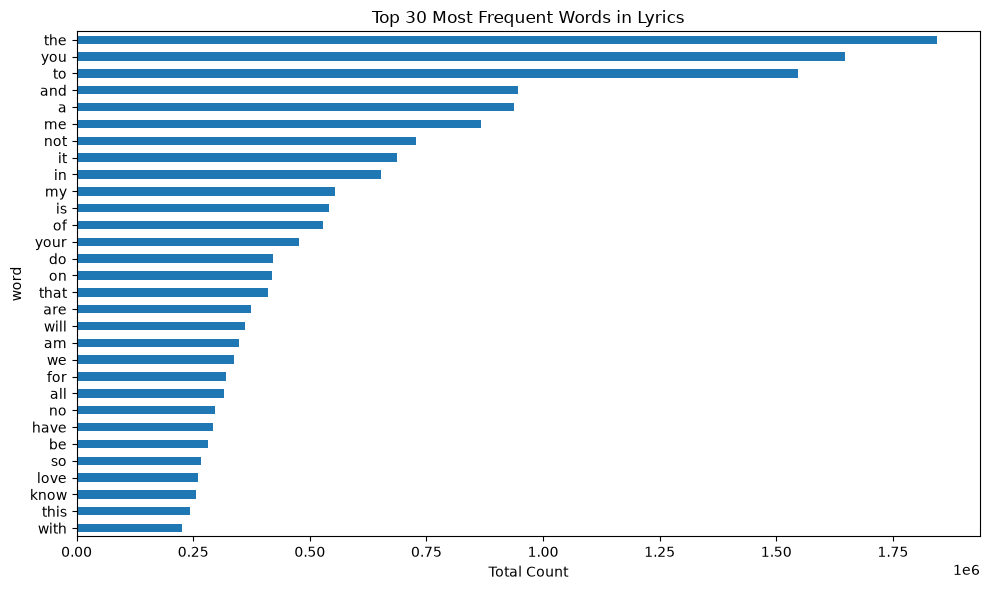

In [11]:
top_words = rs.lyrics_long.groupby("word")["count"].sum().sort_values(ascending=False).head(30)
top_words.plot(kind="barh", figsize=(10, 6), title="Top 30 Most Frequent Words in Lyrics")
plt.xlabel("Total Count")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()